# Instructions

- This homework assignment is worth **51** points. 
- Please strive for clarity and organization.
- **AI Usage**:
   - AI use is strictly **prohibited** for conceptual exercises.
   - For applied (Python) exercises, you may only use AI for **debugging**. Do not use AI to generate answers.
- **Due Date: September 26, 2026, by 11:59 PM.**

# Exercise 1 

In this exercise, we will work with the `winemag-data-130k-v2.csv` data file. This file contains information about wine. The goal is to explore this data using the NLP techniques that we have learnt. For more information about the data file, see this [link](https://www.kaggle.com/datasets/zynicide/wine-reviews/data).

### Exercise 1(a) (2 points)

Load the following libraries as follows:

```
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
from collections import Counter
```

In [1]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
from collections import Counter 

### Exercise 1(b) (2 points)

Read the `csv` file and create a data-frame called `wine_df`.

In [2]:
w = pd.read_csv('DATA/winemag-data-130k-v2.csv')
w.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


### Exercise 1(c) (2 points)

Report the `shape` of `wine_df`.

In [3]:
w.shape

(129971, 14)

### Exercise 1(d) (2 points)

Report the number of wine types in the `wine_df` data frame.

In [4]:
# I assume you mean "Variety" here. 

print(f'There are {w['variety'].nunique()} different varieties and {w['designation'].nunique()} designations. I am not sure which column you are referring to when you say TYPE')

There are 707 different varieties and 37979 designations. I am not sure which column you are referring to when you say TYPE


### Exercise 1(e) (2 points)

Report the number countries producing wine in the `wine_df` data frame.

In [5]:
display('Checking value counts to make sure all countries are actively producing wine.')
display(w['country'].value_counts().sort_values())
display('All countries have at least 1 row')
print(f'There are {w['country'].nunique()} countries producing wine in the wine table.')

'Checking value counts to make sure all countries are actively producing wine.'

country
Egypt                         1
Slovakia                      1
China                         1
Armenia                       2
Bosnia and Herzegovina        2
Luxembourg                    6
Switzerland                   7
India                         9
Cyprus                       11
Czech Republic               12
Serbia                       12
Macedonia                    12
Ukraine                      14
Peru                         16
Morocco                      28
Lebanon                      35
Brazil                       52
Moldova                      59
Mexico                       70
Croatia                      73
England                      74
Georgia                      86
Slovenia                     87
Turkey                       90
Uruguay                     109
Romania                     120
Bulgaria                    141
Hungary                     146
Canada                      257
Greece                      466
Israel                      505


'All countries have at least 1 row'

There are 43 countries producing wine in the wine table.


### Exercise 1(f) (4 points)

Report the country with the highest and lowest average `points`.

In [6]:
avg = w.groupby('country')['points'].mean()

print(f"Highest average points: {avg.idxmax()} ({avg.max():.2f})")
print(f"Lowest average points:  {avg.idxmin()} ({avg.min():.2f})")

Highest average points: England (91.58)
Lowest average points:  Peru (83.56)


### Exercise 1(g) (3 points)

Using the `string` library, remove all the punctuation of the `description` column and store the results in another column called `description_clean`.

In [7]:
import string

w['description_clean'] = w['description'].str.translate(
    str.maketrans('', '', string.punctuation)
)

### Exercise 1(h) (10 points)

Using the `nltk` library, remove stopwords, pronouns, and the following words: `drink`, `now`, `wine`, `flavor`, and `flavors` from `description_clean` and store in another column called `'description_clean_1'`. 

In [8]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')

stop = set(stopwords.words('english'))
extra = {'drink', 'now', 'wine', 'flavor', 'flavors'}

tokens = w['description_clean'].str.lower().str.split()
tagged = nltk.pos_tag_sents(tokens.tolist())

w['description_clean_1'] = [
    ' '.join(
        word for word, tag in doc
        if word not in stop
        and word not in extra
        and tag not in ('PRP', 'PRP$')
    )
    for doc in tagged
]

w[['description_clean', 'description_clean_1']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bdupey\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\bdupey\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


,description_clean,description_clean_1
0,Aromas include tropical fruit broom brimstone ...,aromas include tropical fruit broom brimstone ...
1,This is ripe and fruity a wine that is smooth ...,ripe fruity smooth still structured firm tanni...
2,Tart and snappy the flavors of lime flesh and ...,tart snappy lime flesh rind dominate green pin...
3,Pineapple rind lemon pith and orange blossom s...,pineapple rind lemon pith orange blossom start...
4,Much like the regular bottling from 2012 this ...,much like regular bottling 2012 comes across r...


### Exercise 1(i) (6 points)

Find the top 10 most frequent words in `description_clean_1` of wines from `France`, and visualize the words using a bar chart.

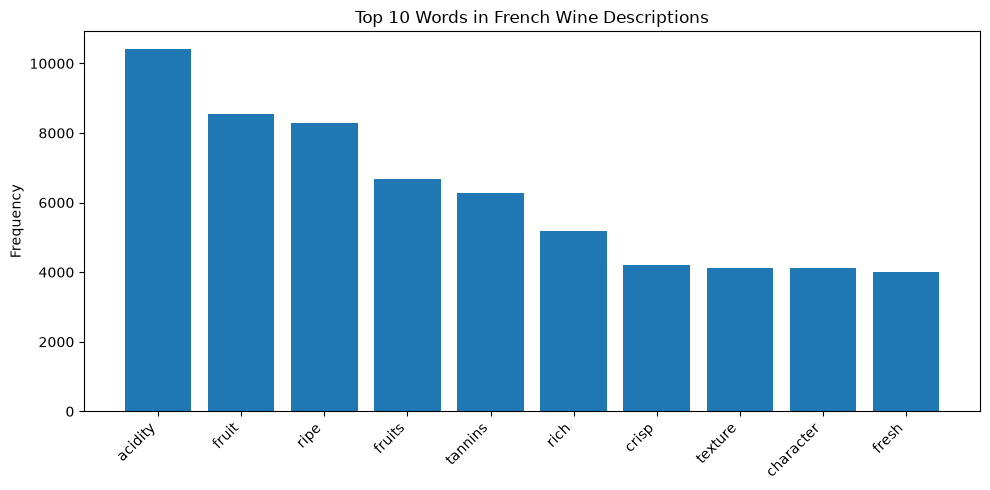

In [9]:
from collections import Counter
import matplotlib.pyplot as plt

france = w.loc[w['country'] == 'France', 'description_clean_1']
counts = Counter(' '.join(france).split()).most_common(10)

words, freqs = zip(*counts)
plt.figure(figsize=(10, 5))
plt.bar(words, freqs)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Words in French Wine Descriptions')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Exercise 1(j) (6 points)

Find the top 10 most frequent words in `description_clean_1` of wines from `Italy`, and visualize the words using a bar chart.

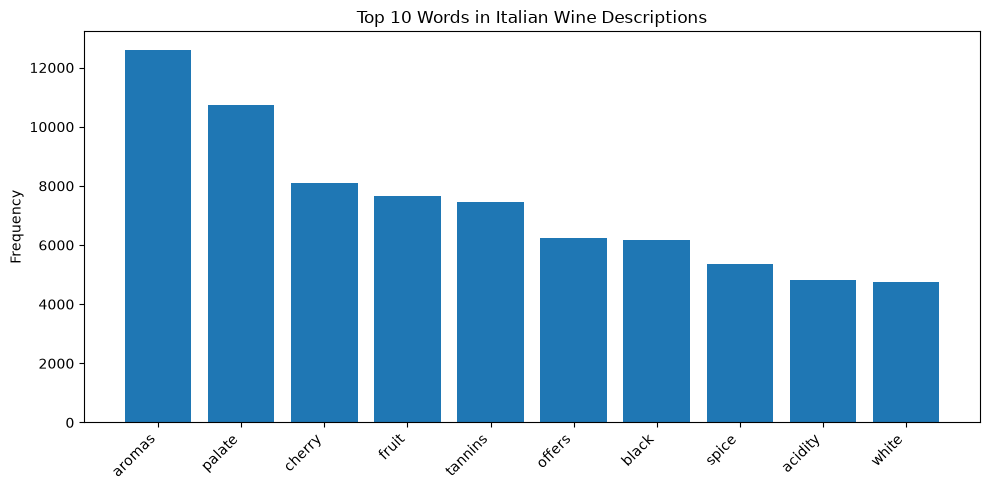

In [10]:
italy = w.loc[w['country'] == 'Italy', 'description_clean_1']
counts = Counter(' '.join(italy).split()).most_common(10)

words, freqs = zip(*counts)
plt.figure(figsize=(10, 5))
plt.bar(words, freqs)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Words in Italian Wine Descriptions')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Exercise 2

The following conceptual questions are based on the NLP pipeline material covered in Chapter 2.

### Exercise 2(a) (2 points)

**Multiple Choice:** According to Chapter 2, which subword tokenization algorithm is used by BERT to handle out-of-vocabulary words?

(A) Byte-Pair Encoding (BPE)

(B) WordPiece

(C) SentencePiece

(D) TF-IDF

(E) None of the above

B

### Exercise 2(b) (4 points)

**Free Response:** Chapter 2 distinguishes between *data (covariate) drift* and *concept drift* during the monitoring and updating stage of the NLP pipeline. In your own words, explain the difference between these two types of drift, and provide one concrete example of each in the context of a real-world NLP application (e.g., a spam filter or a product-review classifier).

With data drift the text coming in changes but the labels still mean what they always did. Like a spam filter that was trained on English email and suddenly starts getting a bunch of Spanish. Spam is still spam, the model just hasn't seen those words.

Concept drift is when the text looks about the same but the meaning of the label moved. A review classifier learns "sick" is a bad sign, then the slang flips and it's a compliment.

So with data drift you retrain on newer data. With concept drift you have to relabel, because the old labels are wrong now.

# Exercise 3

### Exercise 3(a) (6 points)

Chapter 2 introduces **TF-IDF** as a way to convert text into numerical features that down-weight terms appearing in many documents while up-weighting terms that are locally frequent.

Using `TfidfVectorizer` from `sklearn.feature_extraction.text`, compute the TF-IDF representation of the `description_clean_1` column for the `Italy` data frame created in Exercise 1(j). Report the `shape` of the resulting TF-IDF matrix, and print the top 10 terms with the highest average TF-IDF score across all Italian wine reviews.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

italy_df = w[w['country'] == 'Italy']

vec = TfidfVectorizer()
X = vec.fit_transform(italy_df['description_clean_1'])

print(f"TF-IDF matrix shape: {X.shape}")

mean_scores = np.asarray(X.mean(axis=0)).ravel()
terms = vec.get_feature_names_out()

top10 = sorted(zip(terms, mean_scores), key=lambda t: t[1], reverse=True)[:10]

print("\nTop 10 terms by average TF-IDF score:")
for term, score in top10:
    print(f"{term:<15} {score:.4f}")

TF-IDF matrix shape: (19540, 10838)

Top 10 terms by average TF-IDF score:
aromas          0.0422
palate          0.0407
cherry          0.0352
tannins         0.0341
fruit           0.0339
black           0.0334
offers          0.0319
white           0.0282
spice           0.0275
acidity         0.0271
